We consider the following pendulum model:
$$\dot{x}(t) = \\begin{bmatrix}\dot{\theta}(t)\\\\ \\ddot{\theta}(t)\end{bmatrix} = \\begin{bmatrix}x_2(t)\\\\ -\frac{g}{L}\sin(x_1(t)) - \\frac{b}{m}x_2(t)\end{bmatrix}$$
with states $x(t) = [\theta, \\dot{\theta}]^T$ and parameters $p = [g, L, b, m]^T$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import optimize
import time

rng = np.random.default_rng(14588)

We generate a noisy measurement trajectory from the pendulum model using known constants and a reference solver.

In [2]:
g = 9.81
L = 1.0
b = 0.25
m = 0.5
x0 = np.array([0.0, np.pi / 2])
tspan = (0.0, 4.0)
t_eval = np.arange(tspan[0], tspan[1] + 1e-8, 0.05)

def simple_pendulum(t, x):
    return np.array([x[1], -(g / L) * np.sin(x[0]) - (b / m) * x[1]])

sol = solve_ivp(simple_pendulum, tspan, x0, t_eval=t_eval, method='RK45')
t = sol.t
x = sol.y

sigma = 0.05
y = x + sigma * rng.normal(size=x.shape)

Plot the ground truth states and the noisy observations.

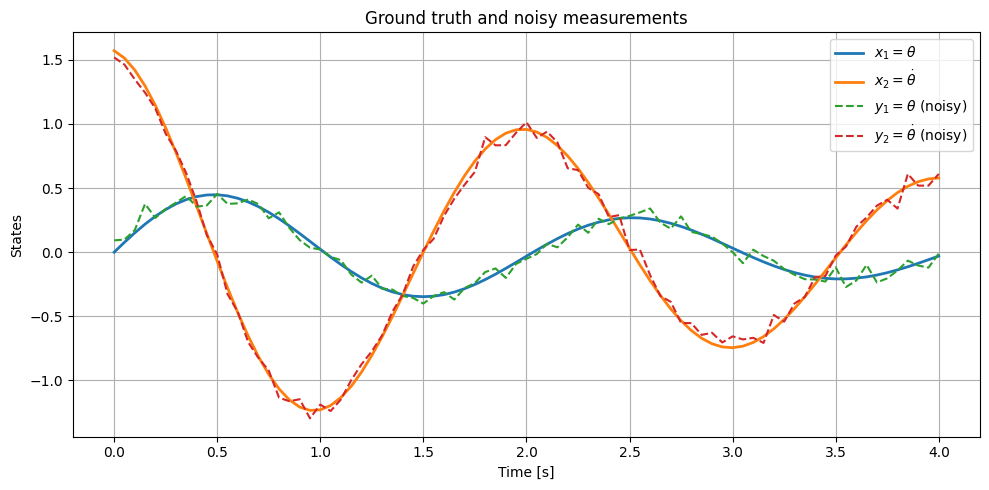

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(t, x[0, :], label=r'$x_1 = \theta$', linewidth=2)
plt.plot(t, x[1, :], label=r'$x_2 = \dot{\theta}$', linewidth=2)
plt.plot(t, y[0, :], '--', label=r'$y_1 = \theta$ (noisy)')
plt.plot(t, y[1, :], '--', label=r'$y_2 = \dot{\theta}$ (noisy)')
plt.xlabel('Time [s]')
plt.ylabel('States')
plt.title('Ground truth and noisy measurements')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

We assume that the pendulum length, mass, and gravity are known, but the friction coefficient $b$ is unknown.

In [4]:
def simple_pendulum_train(t, x, b_est):
    return np.array([x[1], -(g / L) * np.sin(x[0]) - (b_est / m) * x[1]])

def costs(w, y, t_eval, x0):
    b_est = float(w[0])
    sol_est = solve_ivp(lambda t, x: simple_pendulum_train(t, x, b_est), tspan, x0, t_eval=t_eval, method='RK45')
    x_est = sol_est.y
    return np.sum((y - x_est) ** 2)

initial_guess = np.array([1.0])
res = optimize.minimize(costs, initial_guess, args=(y, t_eval, x0), method='BFGS', options={'disp': True})
w_PEM = res.x

Optimization terminated successfully.
         Current function value: 0.384299
         Iterations: 5
         Function evaluations: 18
         Gradient evaluations: 9


Print the identified friction coefficient and compare it to the ground truth.

In [5]:
print('Found parameter b_hat =', w_PEM[0])
print('Ground truth b =', b)

Found parameter b_hat = 0.26109533868669993
Ground truth b = 0.25


Plot the identified model response versus the noisy ground truth data.

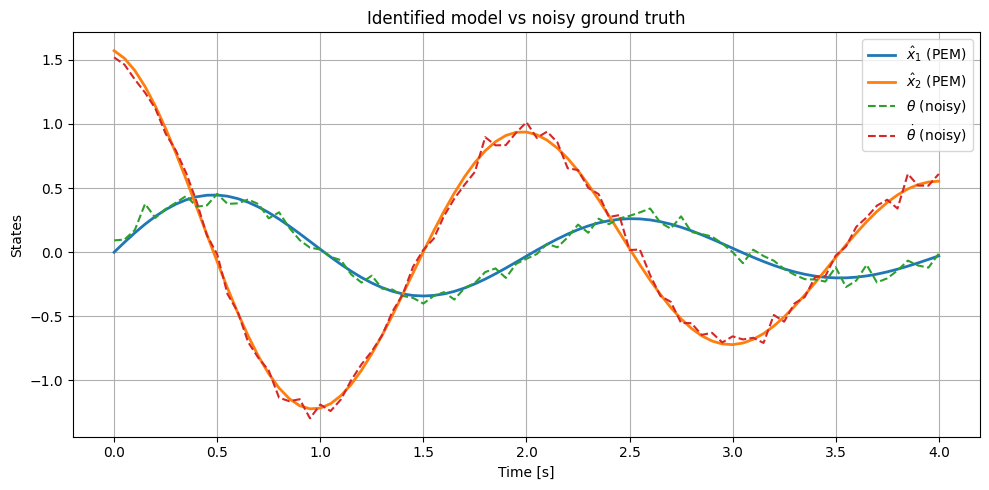

In [6]:
sol_ident = solve_ivp(lambda t, x: simple_pendulum_train(t, x, w_PEM[0]), tspan, x0, t_eval=t_eval, method='RK45')
x_ident = sol_ident.y

plt.figure(figsize=(10, 5))
plt.plot(t, x_ident[0, :], label=r'$\hat{x}_1$ (PEM)', linewidth=2)
plt.plot(t, x_ident[1, :], label=r'$\hat{x}_2$ (PEM)', linewidth=2)
plt.plot(t, y[0, :], '--', label=r'$\theta$ (noisy)')
plt.plot(t, y[1, :], '--', label=r'$\dot{\theta}$ (noisy)')
plt.xlabel('Time [s]')
plt.ylabel('States')
plt.title('Identified model vs noisy ground truth')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Inspect the cost function over a range of friction values.

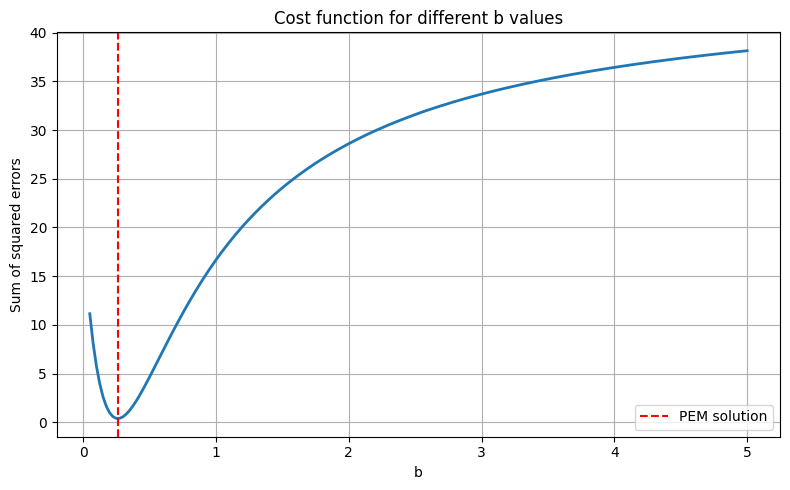

In [7]:
b_vec = np.linspace(0.05, 5.0, 200)
cost_vec = np.array([costs([b_val], y, t_eval, x0) for b_val in b_vec])

plt.figure(figsize=(8, 5))
plt.plot(b_vec, cost_vec, linewidth=2)
plt.axvline(w_PEM[0], color='red', linestyle='--', label='PEM solution')
plt.xlabel('b')
plt.ylabel('Sum of squared errors')
plt.title('Cost function for different b values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Since the initial guess was at 1.0, it is near to the global optimum and thus it got solved in less iterations.

Benchmark the optimization procedure using Python timing.

In [8]:
def run_optimization():
    return optimize.minimize(costs, initial_guess, args=(y, t_eval, x0), method='BFGS', options={'disp': False})

start = time.perf_counter()
run_optimization()
elapsed = time.perf_counter() - start
print(f'Optimization time: {elapsed * 1000:.2f} ms')

Optimization time: 54.64 ms
